Epoch [100/1000], Loss: 0.0006
Epoch [200/1000], Loss: 0.0004
Epoch [300/1000], Loss: 0.0003
Epoch [400/1000], Loss: 0.0003
Epoch [500/1000], Loss: 0.0003
Epoch [600/1000], Loss: 0.0003
Epoch [700/1000], Loss: 0.0003
Epoch [800/1000], Loss: 0.0003
Epoch [900/1000], Loss: 0.0003
Epoch [1000/1000], Loss: 0.0003
Test Loss: 0.0000
Mean Squared Error (MSE): 202755.3750
Root Mean Squared Error (RMSE): 450.2837
Mean Absolute Error (MAE): 313.1278
Mean Absolute Percentage Error (MAPE): 3.9290
R² Score: 0.9660


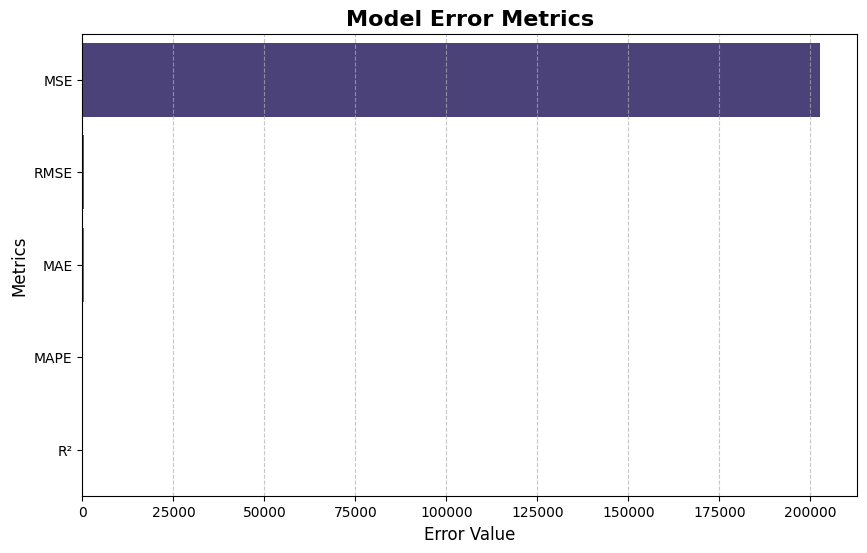

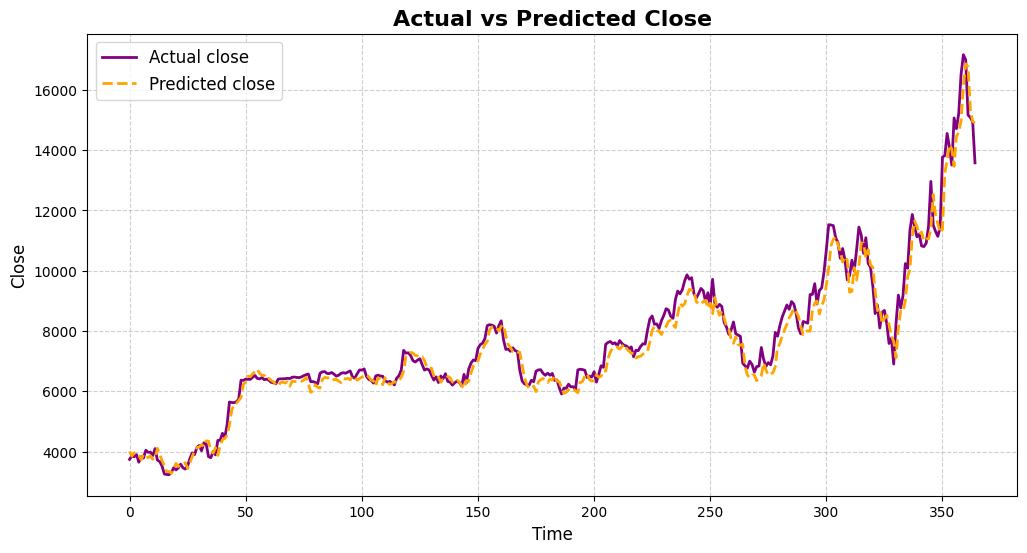

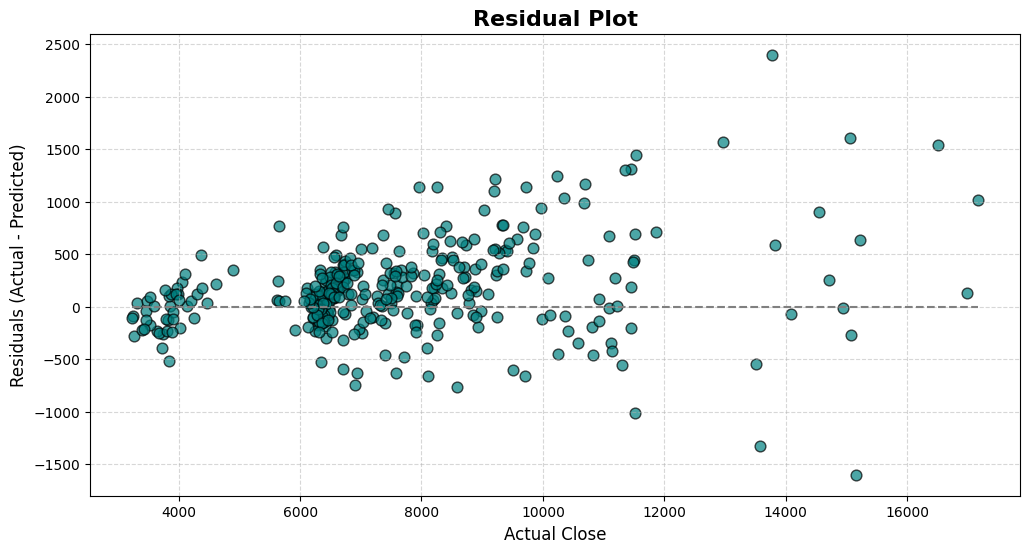

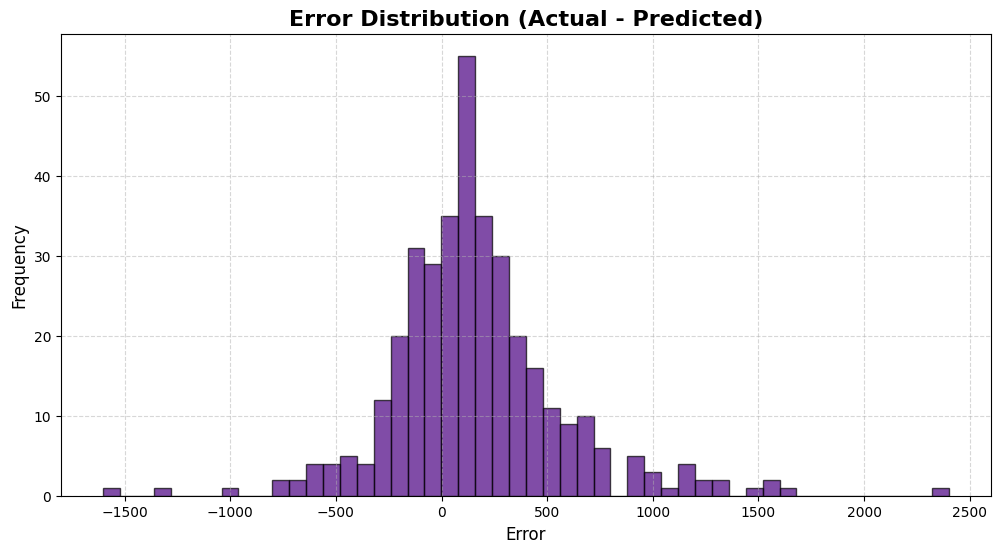

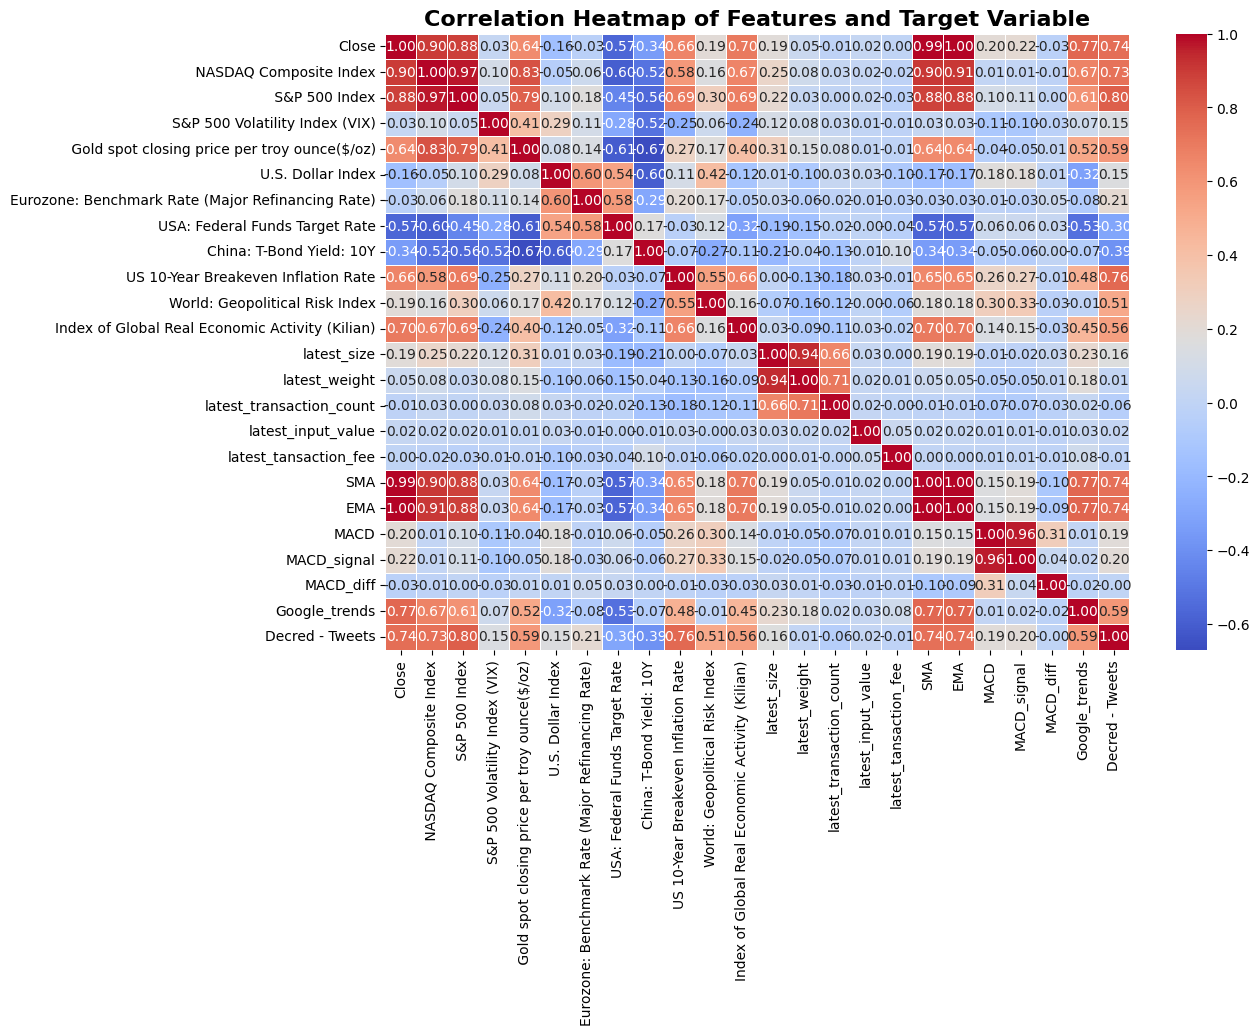

In [2]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.utils import shuffle
import seaborn as sns

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Load the dataset
file_path = 'Bitcoinall.csv'  
data = pd.read_csv(file_path)

# Check for missing values and fill them
data.fillna(method='ffill', inplace=True)

# Remove the first column (assumed to be time column)
data = data.iloc[:, 1:]

# Ensure the target variable is 'close' and the rest are independent variables
target_variable = 'Close'
y = data[target_variable].values

# Normalize the target variable using MinMaxScaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Use the rest of the columns as features (independent variables)
X = data.values

# Normalize the feature variables using MinMaxScaler
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

# Define window size (sequence length)
window_size = 3

# Function to create sequences for GRU
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(y) - window_size):
        X_seq.append(X[i:i+window_size])  # Use the last `window_size` values as input
        y_seq.append(y[i+window_size])  # The next value is the target
    return np.array(X_seq), np.array(y_seq)

# Create sequences
X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define the optimized GRU model class with more layers and dropout
class OptimizedGRUModel(nn.Module):
    def __init__(self):
        super(OptimizedGRUModel, self).__init__()
        self.gru = nn.GRU(input_size=X_train.shape[2], hidden_size=64, num_layers=1, batch_first=True)  # GRU with more layers and dropout
        self.fc = nn.Linear(64, 1)  # Output layer (hidden_size for GRU)

    def forward(self, x):
        gru_out, h_n = self.gru(x)  # GRU outputs
        out = self.fc(gru_out[:, -1, :])  # Get the output from the last GRU timestep
        return out

# Instantiate the model, define the loss function and optimizer
model = OptimizedGRUModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Lower learning rate for better convergence

# Training loop without early stopping
num_epochs = 1000  # Set a higher number of epochs if desired

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    predictions = model(X_train_tensor)

    # Compute loss
    loss = criterion(predictions, y_train_tensor)

    # Backward pass
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Model Evaluation
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

# Inverse transform to get the predictions and actual values in original scale
test_predictions = scaler_y.inverse_transform(test_predictions.cpu().numpy())
y_test_original = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

# Calculate additional evaluation metrics
mse = mean_squared_error(y_test_original, test_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, test_predictions)
mape = np.mean(np.abs((y_test_original - test_predictions) / y_test_original)) * 100
r2 = r2_score(y_test_original, test_predictions)

# Output the metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')
print(f'R² Score: {r2:.4f}')

# Visualization of Metrics (Bar Chart)
metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R²': r2}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()), palette='viridis')
plt.title('Model Error Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Error Value', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Actual vs Predicted (Line Plot)
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual close', color='purple', linewidth=2)
plt.plot(test_predictions, label='Predicted close', color='orange', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Close', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Plot
residuals = y_test_original - test_predictions
plt.figure(figsize=(12, 6))
plt.scatter(y_test_original, residuals, color='teal', edgecolor='black', alpha=0.7, s=60)
plt.hlines(y=0, xmin=y_test_original.min(), xmax=y_test_original.max(), color='gray', linestyle='--', linewidth=1.5)
plt.title('Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Actual Close', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Error Distribution (Histogram)
errors = y_test_original - test_predictions
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.title('Error Distribution (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Correlation Heatmap of Features (Including Target Variable)
data_with_target = data.copy()
data_with_target[target_variable] = y  # Add target column back
correlation_matrix = data_with_target.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features and Target Variable', fontsize=16, fontweight='bold')
plt.show()
